In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [40]:
img = np.random.randint(0, 256, (5, 5))
print(img)

[[153 157 191 253 201]
 [ 17  41  20  40 231]
 [143 171 225 211 108]
 [ 69  26 198   1 231]
 [ 60 231 174 254 119]]


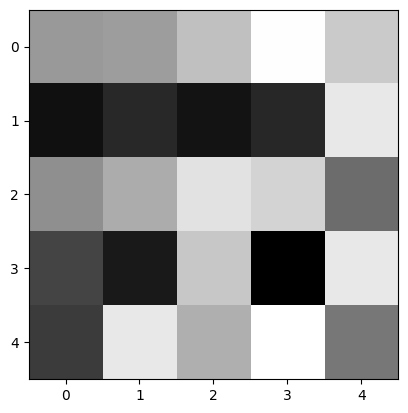

In [41]:
plt.imshow(img, cmap='gray')
plt.show()

In [119]:
def conv2d(image, kernel, clip=True):
    h, w = image.shape
    kh, kw = kernel.shape
    padh, padw = kh//2, kw//2
    padded = np.pad(image, ((padh, padh), (padw, padw)), mode='constant')
    output = np.zeros_like(image, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region*kernel)
    output = np.clip(output, 0, 255)
    if clip:
        output = np.clip(output, 0, 255)
        return output.astype(np.uint8)
    return output

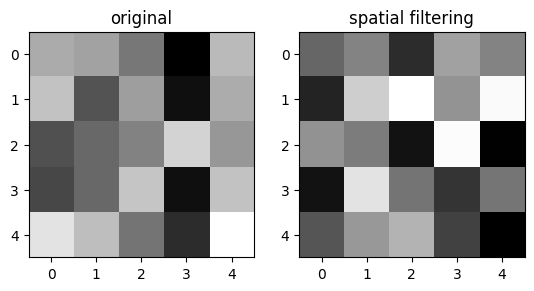

In [32]:
kernel = np.ones((3,3)) # blur 
out = conv2d(img, kernel)
plt.subplot(1, 2, 1)
plt.title('original')
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('spatial filtering')
plt.imshow(out, cmap='gray')
plt.show()

In [33]:
print(f'original\n',img)
print(f'filtered\n',out)

original
 [[173 164 123   8 187]
 [195  88 160  23 174]
 [ 85 108 133 212 154]
 [ 77 108 198  23 195]
 [228 191 120  52 254]]
filtered
 [[108 135  54 163 136]
 [ 45 205 251 150 246]
 [149 128  29 248  13]
 [ 29 224 121  61 122]
 [ 92 154 180  74  12]]


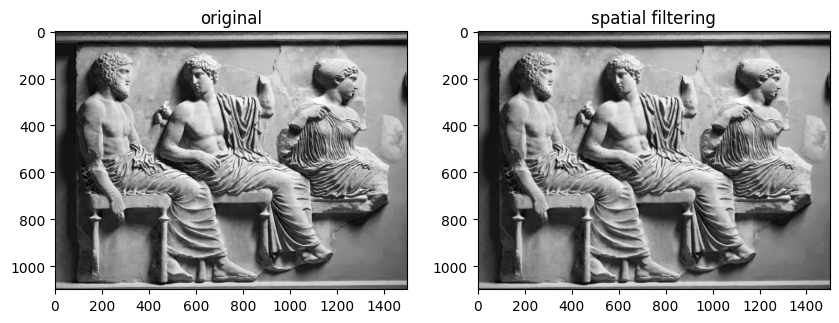

In [125]:
img2 = cv.imread('sculptor.jpg')
img_gray = img2[:, :, 0]
kernel = (1/9)*np.ones((3,3)) # blur 
out = conv2d(img_gray, kernel)
plt.figure(figsize=(10, 9))
plt.subplot(1, 2, 1)
plt.title('original')
plt.imshow(img_gray, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('spatial filtering')
plt.imshow(out, cmap='gray')
plt.show()

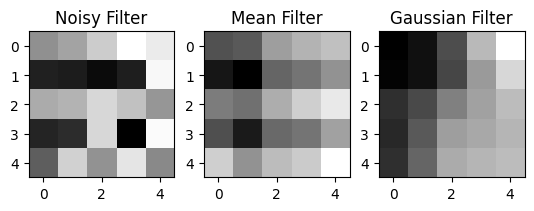

In [44]:
noise = np.random.normal(0, 20, img.shape)
noisy = np.clip(img + noise, 0, 255).astype(np.uint8)
mean = cv.blur(noisy, (5,5))
gaussian = cv.GaussianBlur(noisy, (5,5), 1.0)
plt.subplot(1, 3, 1)
plt.title('Noisy Filter')
plt.imshow(noisy, cmap='gray')
plt.subplot(1, 3, 2)
plt.title('Mean Filter')
plt.imshow(mean, cmap='gray')
plt.subplot(1, 3, 3)
plt.title('Gaussian Filter')
plt.imshow(gaussian, cmap='gray')

In [122]:
def mean_kernel(size):
    return np.ones((size, size), dtype=np.float32) / (size * size)
def gaussian_kernel(size, sigma):
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)
    return kernel
def psnr(original, denoised):
    mse = np.mean((original.astype(np.float32) - denoised.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255 / np.sqrt(mse))
noise = np.random.normal(0, 20, img.shape)
noisy = np.clip(img + noise, 0, 255).astype(np.uint8)
mean_3 = conv2d(noisy, mean_kernel(3))
mean_5 = conv2d(noisy, mean_kernel(5))
gauss_05 = conv2d(noisy, gaussian_kernel(5, 0.5))
gauss_1  = conv2d(noisy, gaussian_kernel(5, 1.0))
gauss_2  = conv2d(noisy, gaussian_kernel(5, 2.0))
print("PSNR (Noisy):", psnr(img, noisy))
print("Mean 3x3:", psnr(img, mean_3))
print("Mean 5x5:", psnr(img, mean_5))
print("Gaussian σ=0.5:", psnr(img, gauss_05))
print("Gaussian σ=1.0:", psnr(img, gauss_1))
print("Gaussian σ=2.0:", psnr(img, gauss_2))

PSNR (Noisy): 21.500206
Mean 3x3: 7.7394395
Mean 5x5: 7.9610543
Gaussian σ=0.5: 14.984465
Gaussian σ=1.0: 8.921415
Gaussian σ=2.0: 8.174663


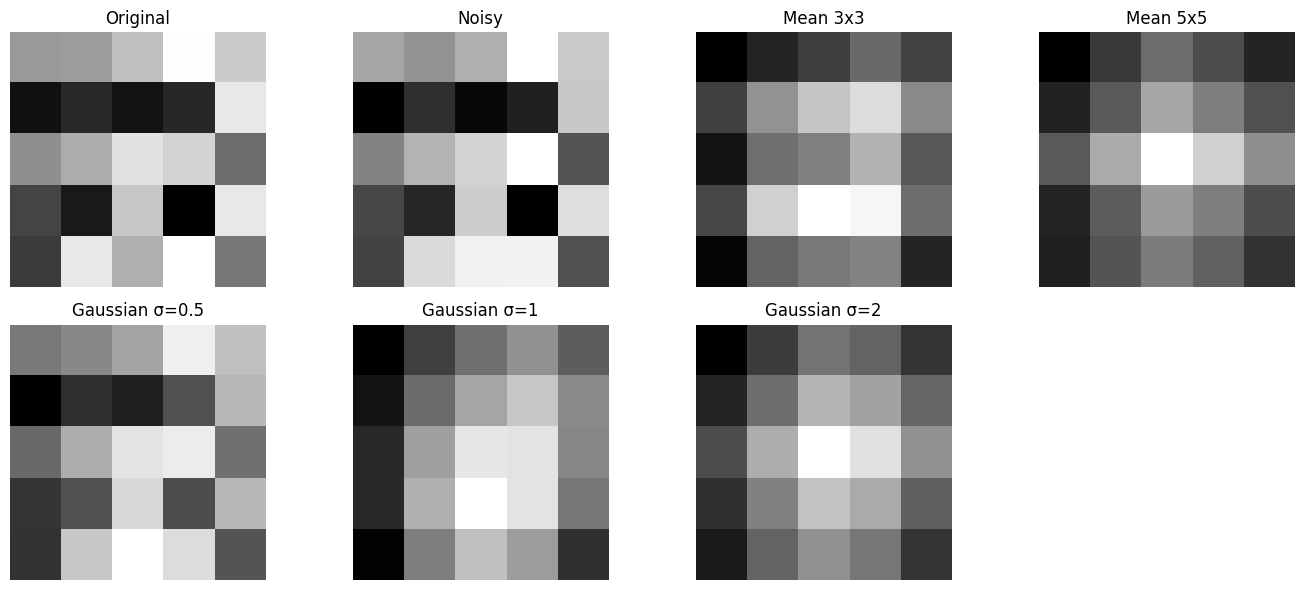

In [123]:
titles = [
    "Original", "Noisy",
    "Mean 3x3", "Mean 5x5",
    "Gaussian σ=0.5", "Gaussian σ=1", "Gaussian σ=2"
]

images = [
    img, noisy,
    mean_3, mean_5,
    gauss_05, gauss_1, gauss_2
]

plt.figure(figsize=(14, 6))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [126]:
def mean_kernel(size):
    return np.ones((size, size), dtype=np.float32) / (size * size)
def gaussian_kernel(size, sigma):
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)
    return kernel
def psnr(original, denoised):
    mse = np.mean((original.astype(np.float32) - denoised.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255 / np.sqrt(mse))
noise = np.random.normal(0, 20, img_gray.shape)
noisy = np.clip(img_gray + noise, 0, 255).astype(np.uint8)
mean_3 = conv2d(noisy, mean_kernel(3))
mean_5 = conv2d(noisy, mean_kernel(5))
gauss_05 = conv2d(noisy, gaussian_kernel(5, 0.5))
gauss_1  = conv2d(noisy, gaussian_kernel(5, 1.0))
gauss_2  = conv2d(noisy, gaussian_kernel(5, 2.0))
print("PSNR (Noisy):", psnr(img_gray, noisy))
print("Mean 3x3:", psnr(img_gray, mean_3))
print("Mean 5x5:", psnr(img_gray, mean_5))
print("Gaussian σ=0.5:", psnr(img_gray, gauss_05))
print("Gaussian σ=1.0:", psnr(img_gray, gauss_1))
print("Gaussian σ=2.0:", psnr(img_gray, gauss_2))

PSNR (Noisy): 22.271088
Mean 3x3: 27.052902
Mean 5x5: 25.01891
Gaussian σ=0.5: 25.79381
Gaussian σ=1.0: 27.392376
Gaussian σ=2.0: 25.741764


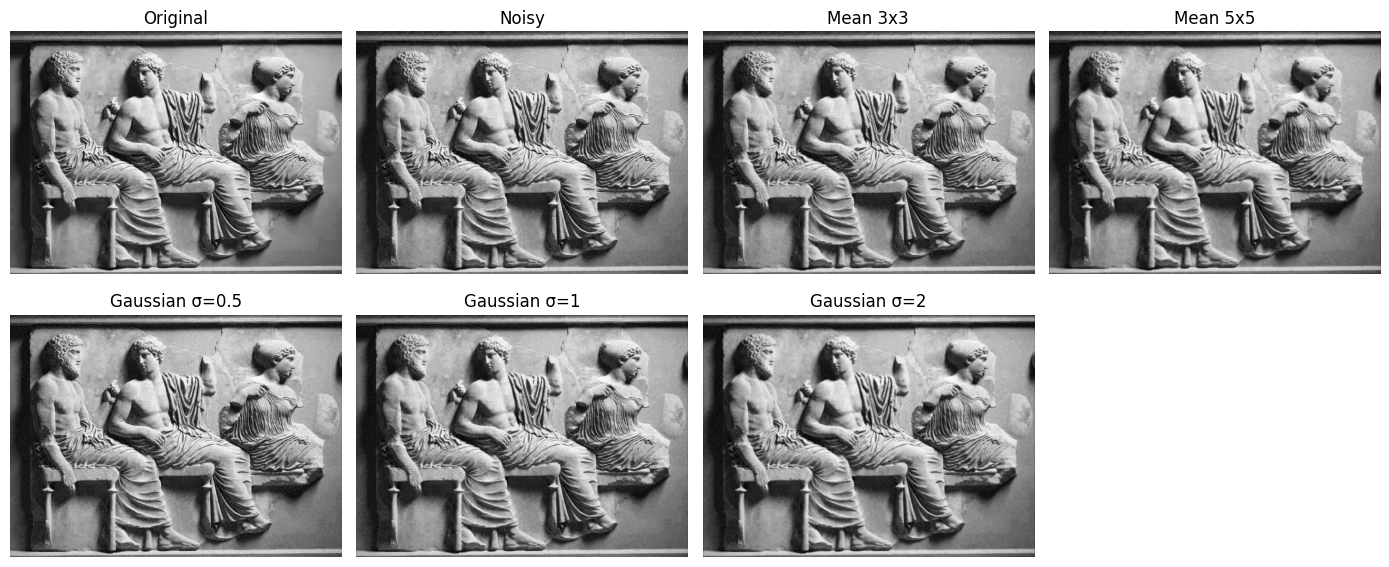

In [127]:
titles = [
    "Original", "Noisy",
    "Mean 3x3", "Mean 5x5",
    "Gaussian σ=0.5", "Gaussian σ=1", "Gaussian σ=2"
]

images = [
    img_gray, noisy,
    mean_3, mean_5,
    gauss_05, gauss_1, gauss_2
]

plt.figure(figsize=(14, 6))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

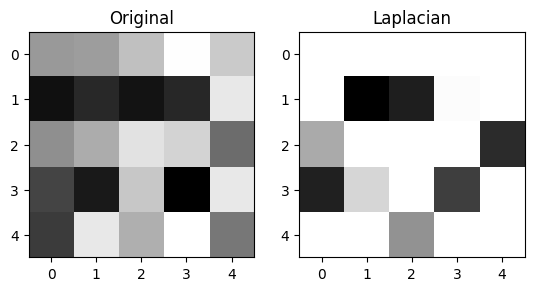

In [ ]:
laplacian = np.array([
        [0, -1, 0],
        [-1, 4, -1],
        [0, -1, 0]
])
edges = conv2d(img, laplacian, clip=False)
sharpened = img + edges
sharpened = np.clip(sharpened, 0, 255)
plt.subplot(1, 2, 1)
plt.title('Original')
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Laplacian')
plt.imshow(sharpened, cmap='gray')

In [101]:
def unsharpmasking(image, k):
    blurkernel = (1/9)*np.ones((3, 3))
    blurimg = conv2d(image, blurkernel)
    output = image + k*(image - blurimg)
    return output

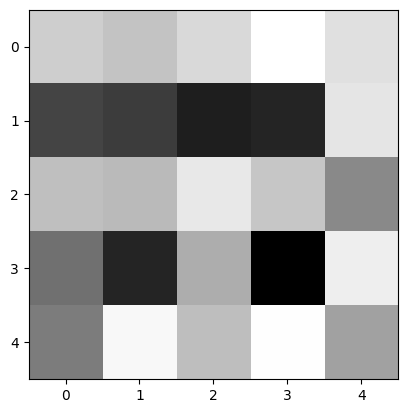

In [102]:
sharpened = unsharpmasking(img, 2)
plt.imshow(sharpened, cmap='gray')

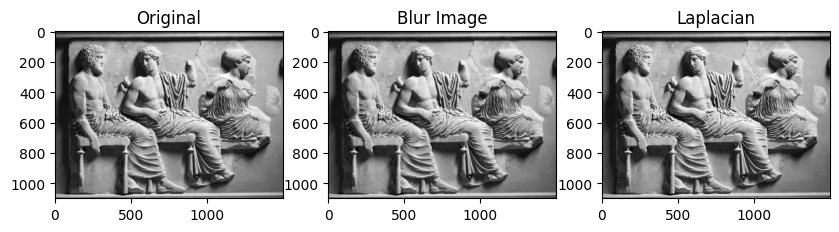

In [121]:
laplacian = np.array([
        [0, -1, 0],
        [-1, 4, -1],
        [0, -1, 0]
])
blurkernel = (1/9)*np.ones((3, 3))
blurimg = conv2d(img_gray, blurkernel, clip=False)
edges = conv2d(blurimg, laplacian, clip=False)
sharpened = img_gray.astype(np.float32) + edges
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
plt.figure(figsize=(10, 6))
plt.subplot(1, 3, 1)
plt.title('Original')
plt.imshow(img_gray, cmap='gray')
plt.subplot(1, 3, 2)
plt.title('Blur Image')
plt.imshow(blurimg, cmap='gray')
plt.subplot(1, 3, 3)
plt.title('Laplacian')
plt.imshow(sharpened, cmap='gray')

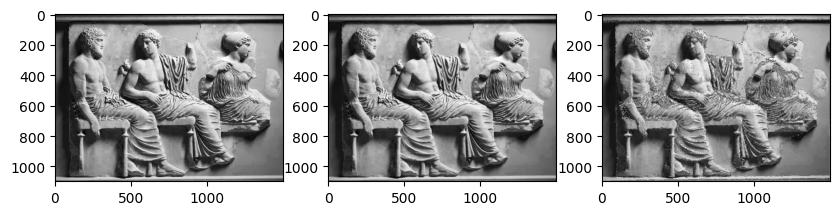

In [111]:
blurkernel = (1/9)*np.ones((3, 3))
blurimg = conv2d(img_gray, blurkernel)
sharpened = unsharpmasking(img_gray, 3)
plt.figure(figsize=(10, 6))
plt.subplot(1,3, 1)
plt.imshow(img_gray, cmap='gray')
plt.subplot(1,3, 2)
plt.imshow(blurimg, cmap='gray')
plt.subplot(1,3, 3)
plt.imshow(sharpened, cmap='gray')

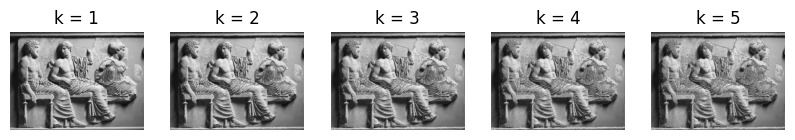

In [116]:
fig, ax = plt.subplots(1, 5, figsize=(10, 6))
for i, k in enumerate([1, 2, 3, 4, 5]):
    sharpened = unsharpmasking(img_gray, k)
    ax[i].imshow(sharpened, cmap='gray')
    ax[i].set_title(f"k = {k}")
    ax[i].axis("off")

plt.show()

In [66]:
def conv2dwithgaussianfilter(image, kh, kw, sigma=1.0):
    h, w = image.shape
    padh, padw = kh//2, kw//2
    
    x = np.linspace(-padw, padw, kw)
    y = np.linspace(-padh, padh, kh)
    xx, yy = np.meshgrid(x, y)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    
    padded = np.pad(image, ((padh, padh), (padw, padw)), mode='edge')
    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
            
    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

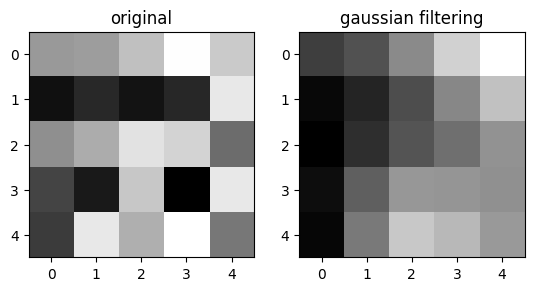

In [82]:
out = conv2dwithgaussianfilter(img, 3, 3)
plt.subplot(1, 2, 1)
plt.title('original')
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('gaussian filtering')
plt.imshow(out, cmap='gray')
plt.show()

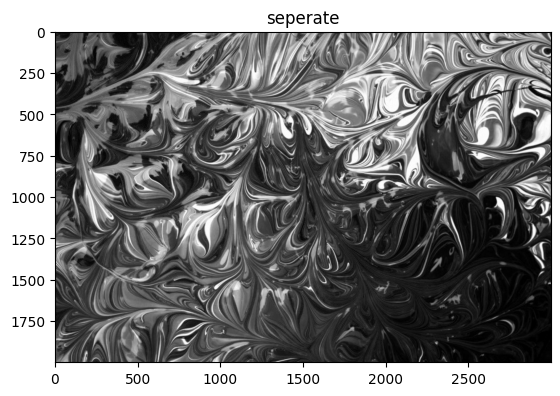

In [77]:
g1d = cv.getGaussianKernel(5, 1)
sep = cv.sepFilter2D(img_gray, ddepth=-1, kernelX=g1d, kernelY=g1d)
direct = cv.GaussianBlur(img_gray, (5,5), 1)
plt.title('seperate')
plt.imshow(sep, cmap='gray')

In [93]:
import random
def add_noise(img):
    row, col = img.shape
    num = int(0.1 * row * col)
    for _ in range(num):
        img[random.randint(0,row-1), random.randint(0,col-1)] = 255
    for _ in range(num):
        img[random.randint(0,row-1), random.randint(0,col-1)] = 0
    return img

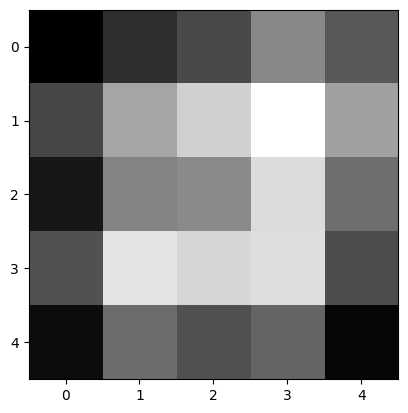

In [94]:
noiseimg = add_noise(img.copy())
blurkernel = (1/9)*np.ones((3, 3))
meanimg = conv2d(noiseimg, blurkernel)
plt.imshow(meanimg, cmap='gray')

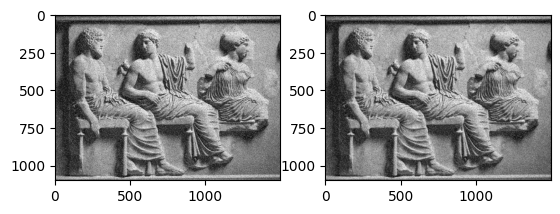

In [96]:
noiseimg = add_noise(img_gray.copy())
blurkernel = (1/9)*np.ones((3, 3))
meanimg = conv2d(noiseimg, blurkernel)
plt.subplot(1,2,1)
plt.imshow(noiseimg, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(meanimg, cmap='gray')

In [98]:
def median_filter(image, ksize=3):
    h, w = image.shape
    p = ksize//2

    padded = np.pad(image, ((p, p), (p, p)), mode='constant')
    output = np.zeros_like(image, dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            region = padded[i:i + ksize, j:j + ksize]
            output[i, j] = np.median(region)
    return output

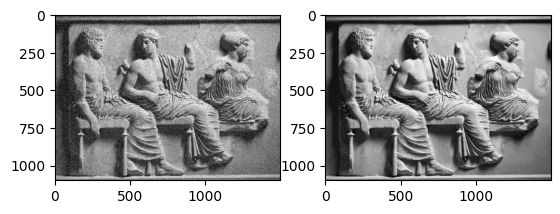

In [100]:
medianimg = median_filter(noiseimg)
plt.subplot(1,2,1)
plt.imshow(noiseimg, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(medianimg, cmap='gray')